<a href="https://colab.research.google.com/github/Adriungs/SQL/blob/main/SQL_B%C3%81SICO/4_GROUPBY_ORDERBY_LIMIT_ASD_DESC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font size = '4'><u><b>FRAGMENTACION DE DATAFRAME</b></u></font>
</center>

En este caso las explicaciónes de los codigos de python no son importantes,sin embargo, si voy a detallar que lo que hizo el codigo en python es crearme 3 tablas dividiendo el contenido del archivo.

 **¿Porque fragmentamos el dataframe?**

  Como necesitamos unir multiples tablas para futuras prácticas lo conveniente es dividirlo usando solo una base de datos.

Otras bases de datos podrian no estar correlacionadas y estaremos juntando datos diferentes ó que nada tienen que ver con lo que estamos analizando.

En las aplicaciones reales se usan multiples tablas de diferentes sectores eso es lo que hicimos al fragmentar.

Si lo pensamos en aplicaciones reales hay tres sectores que requieren diferentes tablas:


1.   Clientes
2.   Productos
3.   Ventas



In [ ]:
#Nueva base de datos
!pip install jupysql --quiet

In [ ]:
import pandas as pd
import sqlite3

# 1. Cargar el archivo con tus columnas reales
df_original = pd.read_csv('retail_ferreteria.csv')

# 2. Normalización ajustada a tu dataset

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

# 3. Guardar en el motor SQLite
conn = sqlite3.connect('ferreteria.db')

try:
  clientes.to_sql('clientes', conn, if_exists='replace', index=False)
  productos.to_sql('productos', conn, if_exists='replace', index=False)
  ventas.to_sql('ventas', conn, if_exists='replace', index=False)
finally:
    conn.close()  # <-- Esto libera el archivo y evita el error "database is locked"

print("¡Base de datos 'ferreteria.db' creada y liberada con éxito!")



¡Base de datos 'ferreteria.db' creada y liberada con éxito!


In [ ]:
%load_ext sql
%sql sqlite:///ferreteria.db
%config SqlMagic.feedback = False
%config SqlMagic.displaylimit = 0

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


<center>
<font size = '6' color =BLACK><u><b>Filtrado y ordenación de resultados de consultas-
DISTINCT<b/></u></font>
</center>

SQL ofrece una forma práctica de descartar filas con valores duplicados en las columnas mediante "DISTINCT" palabra clave: `descartar filas`.

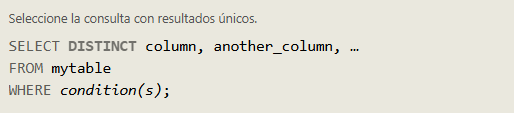

Se puede ver como espera que ciertas columnas traigan datos distintos esto se usa para identificar también fallas de ortografia entre otros fallos, en los datos brindados

Muchas veces no basta con ver “qué registros cumplen una condición”. También queremos:

Ordenar los resultados de menor a mayor o al revés.
Mostrar solo los primeros registros (por ejemplo: los 5 alumnos más jóvenes).

-Para esto existen dos herramientas muy importantes en SQL:

* **ORDER BY** → para ordenar los resultados.

* **LIMIT** → para limitar cuántos resultados se muestran.

Aunque recién aparezca la explicación de limit nosotros venimos usandolo desde la clase 1, ya que era imprescindible para que nuestros proyectos se puedan observar y analizar

<center>
<font size = '6' color =black><u><b>ORDER BY<b/></u></font>
</center>

La mayoría de los datos en las bases de datos reales se agregan sin un orden específico de columnas. Por lo tanto, puede resultar difícil leer y comprender los resultados de una consulta a medida que el tamaño de la tabla aumenta a miles o incluso millones de filas.

Para ayudar con esto, SQL proporciona una forma de ordenar los resultados por una columna determinada en orden ascendente o descendente utilizando ORDER BY.

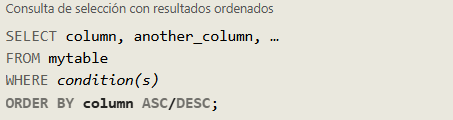

En la imagen se puede ver la estructura de todo lo que estamos viendo esto nos sirve para saber los pasos y el orden en el que se resuelve.

<font size = '4' color =black><u><b>ASC--DESC<b/></u></font>
* ASC → orden ascendente (menor a mayor, de A a Z). (valor por defecto)
* DESC → orden descendente (mayor a menor, de Z a A).

Cuando ORDER BY se especifica una cláusula, cada fila se ordena alfanuméricamente según el valor de la columna especificada. En algunas bases de datos, también se puede especificar una intercalación para ordenar mejor los datos que contienen texto internacional.



<center>
<font size = '6' color =black><u><b>Limitar los resultados a un subconjunto<b/></u></font>
</center>

Otra cláusula que se usa comúnmente con la ORDER BY son las cláusulas:

 LIMIT y OFFSET, que son una optimización útil para indicar a la base de datos el subconjunto de resultados que le interesa.
* LIMIT reducirá la cantidad de filas a devolver

* OFFSET, es opcional y especificará desde dónde comenzar a contar la cantidad de filas.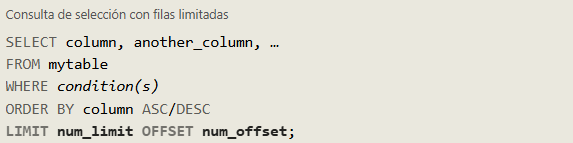

<center>
<font size = '6' color =black><u><b>EJERCICIOS<b/></u></font>
</center>

1- Ordenar el nombres de las herramientas en orden alfabético

In [ ]:
%%sql
SELECT id_cliente, nombre_cliente
FROM clientes
ORDER BY nombre_cliente ASC
LIMIT 20



id_cliente,nombre_cliente
7925,Abigail Angel Gabriel Barrios Figueroa
6103,Abigail Delfina Juarez Herrera
5068,Abigail Thiago Ezequiel Bustos
6782,Abril Diaz Figueroa
6673,Abril Fernandez
7388,Abril Fernandez Ramirez
6460,Abril Garcia Diaz
9240,Abril Isabella Leiva Peralta
1107,Abril Juan Manuel Martin Vargas
8606,Abril Pilar Sosa


2-Ahora ordenar los nombres de la Z a la A

In [ ]:
%%sql
SELECT id_cliente, nombre_cliente
FROM clientes
ORDER BY nombre_cliente DESC
LIMIT 20

id_cliente,nombre_cliente
9653,Zoe Valentina Sofia Rodriguez Aguirre
4197,Zoe Valentina Salvador Caceres
4915,Zoe Valentina Morales
2293,Zoe Valentina Molina
8469,Zoe Valentina Lucas Benjamin Muñoz
8738,Zoe Valentina Hernandez Roldan
6141,Zoe Valentina Gomez
2916,Zoe Valentina Alvarez Ruiz
6729,Zoe Valentina Agustin Morales
6164,Zoe Ramirez


3- Ver las distintas herramientas que vendimos y su cantidad

In [ ]:
%%sql
SELECT DISTINCT producto, cantidad
FROM ventas
ORDER BY producto ASC
LIMIT 20

producto,cantidad
Caja de tornillos,2.0
Caja de tornillos,4.0
Caja de tornillos,1.0
Caja de tornillos,5.0
Caja de tornillos,None
Caja de tornillos,3.0
Cinta métrica,5.0
Cinta métrica,4.0
Cinta métrica,1.0
Cinta métrica,None


La cláusula DISTINCT sí está funcionando, pero está evaluando la combinación de ambas columnas (producto y cantidad) al mismo tiempo, no solo el producto de forma individual.Esto significa que si en tu tabla tienes el mismo producto con diferentes cantidades vendidas, SQL considerará que cada fila es única y te mostrará ambas.Ejemplo de cómo actúa DISTINCT en tu consultaSi tus datos originales en la tabla ventas son:

producto -----cantidad
---

Pantalón----------------2

---

Pantalón---------------- 2

---
Pantalón --------------- 5

---

Ademas podemos ver herraminetos en la parte de venta con NaN vendidas

4- Ahora vamos a buscar productos unicos a ver si nos encontramos con productos con falta de ortografia tanto la tabla productos como en la tabla ventas

In [ ]:
%%sql
SELECT DISTINCT producto
FROM ventas
ORDER BY producto ASC
LIMIT 20

producto
Caja de tornillos
Cinta métrica
Destornillador
Guantes de trabajo
Llave inglesa
Martillo
Pintura látex 4L
Rodillo de pintura
Sierra circular
Taladro eléctrico


In [ ]:
%%sql
SELECT DISTINCT producto
FROM productos
ORDER BY producto ASC
LIMIT 20

producto
Caja de tornillos
Cinta métrica
Destornillador
Guantes de trabajo
Llave inglesa
Martillo
Pintura látex 4L
Rodillo de pintura
Sierra circular
Taladro eléctrico


Aca verificamos que no hay faltas de ortografías

5- Por ultimo vamos a ver las ultimas 7 herramientas vendidas segun la fecha

In [ ]:
%%sql
SELECT id_venta, producto, fecha_hora
FROM ventas
ORDER BY fecha_hora DESC
LIMIT 7

id_venta,producto,fecha_hora
494,Llave inglesa,2025-09-16 10:56:40
2393,Taladro eléctrico,2025-09-16 06:13:07
1123,Caja de tornillos,2025-09-16 05:36:21
2120,Cinta métrica,2025-09-15 18:04:14
457,Pintura látex 4L,2025-09-15 13:29:33
994,Taladro eléctrico,2025-09-15 07:44:40
1207,Cinta métrica,2025-09-15 06:39:08
